# Feature Selection untuk Sales Planner (Pricing Decision)

Tujuan: Menentukan variabel non-KPI mana yang paling berkorelasi dengan
KPI-KPI yang relevan untuk Sales Planner dalam menentukan harga.

## Alur
1. Pisahkan kolom menjadi **KPI** (dari `kpis.md`) dan **Non-KPI** (original data)
2. Pilih 9 KPI yang relevan untuk Sales Planner (domain knowledge)
3. Analisis korelasi setiap selected KPI vs seluruh non-KPI variables
4. Composite scoring & ranking fitur (elbow method)
5. Validasi dengan Random Forest (RMSE comparison)
6. Rekomendasi fitur final


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('OK Libraries loaded')


OK Libraries loaded


In [2]:
df = pd.read_csv('../df_kpi_all_players.csv')
df = df.sort_values(['team_name', 'month']).reset_index(drop=True)
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {df.columns.tolist()}')


Shape: (144, 48)
Columns (48): ['team_name', 'team_id', 'month', 'total_market', 'competitor_demand', 'firm_demand', 'competitor_price', 'beginning_inventory', 'arrival_qty', 'units_sold', 'ending_inventory', 'in_transit', 'production_order', 'pipeline_units', 'months_of_cover', 'forecast_error', 'service_level', 'revenue_amt', 'cogs_amt', 'inventory_holding_amt', 'stockout_penalty_amt', 'forecast_made', 'price', 'ai_price', 'ai_forecast_qty', 'ai_production_order', 'unit_cost', 'revenue_growth', 'gross_margin', 'operating_profit', 'market_share', 'ms_momentum', 'ms_momentum_3mo', 'rpi', 'missed_demand', 'stockout_rate', 'fill_rate', 'ape', 'forecast_accuracy', 'mape', 'forecast_accuracy_avg', 'forecast_bias', 'avg_inventory', 'inventory_turnover', 'inventory_turnover_annualized', 'price_elasticity', 'cps', 'ppi']


## Section 2 — Definisi KPI vs Non-KPI

Berdasarkan panduan `kpis.md`, kolom dikelompokkan menjadi:
- **KPI columns**: metrik-metrik yang didefinisikan sebagai KPI
- **Non-KPI columns**: data original + derived variables yang bukan KPI


In [3]:
kpi_columns = [
    'revenue_amt', 'revenue_growth',
    'gross_margin', 'operating_profit',
    'market_share', 'ms_momentum', 'ms_momentum_3mo',
    'rpi',
    'service_level', 'fill_rate', 'stockout_rate', 'missed_demand',
    'forecast_error', 'forecast_accuracy', 'mape',
    'forecast_accuracy_avg', 'forecast_bias',
    'months_of_cover', 'pipeline_units',
    'inventory_turnover', 'inventory_turnover_annualized',
    'price_elasticity', 'cps', 'ppi',
]

non_kpi_columns = [
    'total_market', 'competitor_demand', 'firm_demand',
    'competitor_price',
    'beginning_inventory', 'arrival_qty', 'units_sold',
    'ending_inventory', 'in_transit', 'production_order',
    'forecast_made',
    'price', 'ai_price',
    'ai_forecast_qty', 'ai_production_order',
    'cogs_amt', 'inventory_holding_amt', 'stockout_penalty_amt',
    'unit_cost', 'avg_inventory',
]

print(f'KPI columns ({len(kpi_columns)}): {kpi_columns}')
print(f'Non-KPI columns ({len(non_kpi_columns)}): {non_kpi_columns}')

# verify no overlap
overlap = set(kpi_columns) & set(non_kpi_columns)
print(f'Overlap: {overlap if overlap else "None"}')

# verify all columns accounted for
id_cols = ['team_name', 'team_id', 'month']
all_accounted = id_cols + kpi_columns + non_kpi_columns
missing = [c for c in df.columns if c not in all_accounted]
print(f'Missing from grouping: {missing if missing else "None"}')


KPI columns (24): ['revenue_amt', 'revenue_growth', 'gross_margin', 'operating_profit', 'market_share', 'ms_momentum', 'ms_momentum_3mo', 'rpi', 'service_level', 'fill_rate', 'stockout_rate', 'missed_demand', 'forecast_error', 'forecast_accuracy', 'mape', 'forecast_accuracy_avg', 'forecast_bias', 'months_of_cover', 'pipeline_units', 'inventory_turnover', 'inventory_turnover_annualized', 'price_elasticity', 'cps', 'ppi']
Non-KPI columns (20): ['total_market', 'competitor_demand', 'firm_demand', 'competitor_price', 'beginning_inventory', 'arrival_qty', 'units_sold', 'ending_inventory', 'in_transit', 'production_order', 'forecast_made', 'price', 'ai_price', 'ai_forecast_qty', 'ai_production_order', 'cogs_amt', 'inventory_holding_amt', 'stockout_penalty_amt', 'unit_cost', 'avg_inventory']
Overlap: None
Missing from grouping: ['ape']


## Section 3 — Seleksi KPI Sales Planner (Domain Knowledge)

Dari seluruh KPI, dipilih 9 yang paling relevan untuk Sales Planner
dalam menentukan harga, berdasarkan panduan `kpis.md`:

| # | KPI | Kategori | Alasan Relevansi |
|---|-----|----------|-----------------|
| 1 | `revenue_growth` | Growth | Target utama pricing — harga memengaruhi pertumbuhan revenue |
| 2 | `gross_margin` | Profitability | = (P - Cost)/P, fungsi langsung dari price |
| 3 | `operating_profit` | Profitability | Profit akhir setelah biaya — tujuan bisnis |
| 4 | `market_share` | Competitive | Harga menentukan posisi kompetitif |
| 5 | `rpi` | Competitive | Posisi harga relatif ke kompetitor |
| 6 | `service_level` | Operational Constraint | Harga tinggi → demand turun → SL naik (inventory cukup); price rendah → demand naik → SL turun (stockout) |
| 7 | `price_elasticity` | Strategic Pricing | Sensitivitas demand terhadap price |
| 8 | `ppi` | Strategic Pricing | Kemampuan menaikkan harga tanpa kehilangan pangsa pasar |
| 9 | `cps` | Strategic Pricing | Tekanan kompetitif pada pricing |


In [4]:
selected_kpis = [
    'revenue_growth',
    'gross_margin',
    'operating_profit',
    'market_share',
    'rpi',
    'service_level',
    'price_elasticity',
    'ppi',
    'cps',
]

print(f'Selected KPIs for Sales Planner ({len(selected_kpis)}):')
for i, k in enumerate(selected_kpis, 1):
    print(f'  {i}. {k}')


Selected KPIs for Sales Planner (9):
  1. revenue_growth
  2. gross_margin
  3. operating_profit
  4. market_share
  5. rpi
  6. service_level
  7. price_elasticity
  8. ppi
  9. cps


## Section 4 — Data Cleaning

Menangani missing values, infinite values, dan memastikan data siap
untuk analisis korelasi.


In [5]:
analyze_df = df[id_cols + selected_kpis + non_kpi_columns].copy()

# Replace inf dengan NaN
numeric_cols = selected_kpis + non_kpi_columns
analyze_df[numeric_cols] = analyze_df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Drop rows dengan NaN pada selected KPIs atau non-KPI
before = len(analyze_df)
analyze_df = analyze_df.dropna(subset=numeric_cols)
after = len(analyze_df)
print(f'Rows dropped due to NaN: {before - after}')
print(f'Remaining rows: {after}')
print(f'Unique teams: {analyze_df["team_name"].nunique()}')
print(f'Month range: {analyze_df["month"].min()} - {analyze_df["month"].max()}')


Rows dropped due to NaN: 44
Remaining rows: 100
Unique teams: 12
Month range: 2 - 12


In [6]:
print('Missing values per column:')
missing = analyze_df[numeric_cols].isnull().sum()
print(missing[missing > 0] if any(missing > 0) else '  None')


Missing values per column:
  None


In [7]:
print('Basic statistics of selected KPIs:')
analyze_df[selected_kpis].describe().round(4)


Basic statistics of selected KPIs:


,revenue_growth,gross_margin,operating_profit,market_share,rpi,service_level,price_elasticity,ppi,cps
count,100.0000,100.0000,100.000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000
mean,0.1903,0.4099,2890.400,0.4963,0.0644,0.8971,-4.2738,0.3486,0.0141
std,0.4184,0.1175,2436.271,0.1037,0.1473,0.1815,10.4770,0.1171,0.0242
min,-0.8779,0.0000,-3220.000,0.1667,-0.2537,0.0976,-64.6341,0.0000,-0.0172
25%,-0.0261,0.3569,1393.750,0.4603,-0.0262,0.8434,-6.6749,0.2796,-0.0002
50%,0.1489,0.4253,2370.500,0.5062,0.0556,1.0000,-2.1390,0.3750,0.0030
75%,0.3065,0.4949,3774.500,0.5456,0.1290,1.0000,-0.4620,0.4303,0.0207
max,1.6807,0.6667,10222.000,0.7981,0.6484,1.0000,19.3860,0.5248,0.1164


In [8]:
print('Basic statistics of non-KPI variables:')
analyze_df[non_kpi_columns].describe().round(4)


Basic statistics of non-KPI variables:


,total_market,competitor_demand,firm_demand,competitor_price,beginning_inventory,arrival_qty,units_sold,ending_inventory,in_transit,production_order,forecast_made,price,ai_price,ai_forecast_qty,ai_production_order,cogs_amt,inventory_holding_amt,stockout_penalty_amt,unit_cost,avg_inventory
count,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0,100.0000
mean,256.7400,130.9200,125.8200,82.9600,67.0600,116.5900,112.1800,71.470,227.0500,112.2500,116.4200,87.9400,85.8000,123.0700,198.0000,5609.0000,714.7000,272.8000,50.0,69.2650
std,115.5182,70.3072,62.7492,13.8045,99.7077,120.9406,62.3968,110.562,189.7194,126.5301,65.8848,17.1834,12.9396,67.7508,172.9016,3119.8402,1105.6197,481.1394,0.0,91.7527
min,84.0000,21.0000,31.0000,60.0000,0.0000,0.0000,8.0000,0.000,0.0000,0.0000,23.0000,50.0000,60.0000,23.0000,0.0000,400.0000,0.0000,0.0000,50.0,0.0000
25%,134.0000,64.0000,64.0000,72.0000,0.0000,50.0000,58.5000,0.000,107.5000,0.0000,58.0000,77.7500,76.0000,58.0000,50.0000,2925.0000,0.0000,0.0000,50.0,13.0000
50%,302.0000,131.0000,128.5000,81.0000,34.5000,100.0000,101.5000,28.500,164.5000,100.0000,100.0000,87.0000,87.0000,110.0000,150.0000,5075.0000,285.0000,0.0000,50.0,41.7500
75%,350.0000,179.2500,173.0000,91.0000,83.2500,150.0000,155.7500,90.500,302.5000,150.0000,170.7500,99.0000,95.0000,181.2500,250.0000,7787.5000,905.0000,505.0000,50.0,84.1250
max,400.0000,320.0000,298.0000,121.0000,552.0000,700.0000,298.0000,552.000,860.0000,700.0000,285.0000,150.0000,125.0000,237.0000,700.0000,14900.0000,5520.0000,2060.0000,50.0,511.5000


## Section 5 — Korelasi: Selected KPIs vs Non-KPI Variables

Tiga metode digunakan untuk menangkap berbagai jenis hubungan:
- **Pearson r**: hubungan linear
- **Spearman ρ**: hubungan monotonik (termasuk non-linear monotonik)
- **Mutual Information**: hubungan non-linear umum (tanpa asumsi distribusi)


### 5.1 — Pearson Correlation


In [9]:
def pearson_matrix(targets, features, data):
    result = pd.DataFrame(index=targets, columns=features, dtype=float)
    for t in targets:
        for f in features:
            r = data[[t, f]].corr(method='pearson').iloc[0, 1]
            result.loc[t, f] = r if not np.isnan(r) else 0
    return result

pearson_r = pearson_matrix(selected_kpis, non_kpi_columns, analyze_df)
print('Pearson Correlation: Selected KPIs (rows) vs Non-KPI variables (cols)')
pearson_r


Pearson Correlation: Selected KPIs (rows) vs Non-KPI variables (cols)


,total_market,competitor_demand,firm_demand,competitor_price,beginning_inventory,arrival_qty,units_sold,ending_inventory,in_transit,production_order,forecast_made,price,ai_price,ai_forecast_qty,ai_production_order,cogs_amt,inventory_holding_amt,stockout_penalty_amt,unit_cost,avg_inventory
revenue_growth,0.069234,-0.024841,0.155289,0.128984,0.024046,0.149010,0.294013,0.018754,-0.001849,-0.099045,0.010326,-0.167117,0.048946,0.010639,-0.144231,0.294013,0.018754,-0.357536,0.0,0.024365
gross_margin,-0.027237,0.261721,-0.343386,0.697588,-0.253159,-0.210109,-0.393692,-0.235954,-0.133729,-0.130746,-0.373383,0.948613,0.710126,-0.265130,-0.186889,-0.393692,-0.235954,0.125450,0.0,-0.279716
operating_profit,0.517761,0.529136,0.360303,0.695088,-0.029687,0.003849,0.371181,-0.232042,-0.025250,-0.113212,0.180791,0.554565,0.412304,0.267588,0.251670,0.371181,-0.232042,-0.022936,0.0,-0.155936
market_share,-0.134592,-0.553310,0.372177,-0.061937,0.346348,0.169990,0.424222,0.258879,-0.171013,-0.097575,0.230817,-0.678472,-0.164475,0.099432,0.131888,0.424222,0.258879,-0.129539,0.0,0.344163
rpi,-0.105303,0.301132,-0.531261,-0.179154,-0.253271,-0.299134,-0.538063,-0.251959,0.035962,0.042514,-0.383162,0.569370,0.076545,-0.285918,-0.237596,-0.538063,-0.251959,0.009861,0.0,-0.289420
service_level,-0.183024,-0.246243,-0.061035,-0.088619,0.270612,0.267253,0.294180,0.370362,-0.251596,-0.240365,0.002936,-0.159784,-0.039136,-0.103733,-0.197877,0.294180,0.370362,-0.922220,0.0,0.370180
price_elasticity,0.013826,0.033541,-0.012128,-0.030758,-0.121348,0.085525,0.018765,-0.026473,-0.014325,-0.033222,0.143574,-0.011312,-0.136320,0.178808,0.142795,0.018765,-0.026473,-0.080305,0.0,-0.081884
ppi,-0.199630,-0.041438,-0.321081,0.609149,-0.050145,0.012489,-0.147976,0.051951,-0.285017,-0.271508,-0.343357,0.661759,0.650580,-0.329186,-0.317892,-0.147976,0.051951,-0.453686,0.0,0.004054
cps,0.130513,0.276783,-0.069852,-0.171973,0.031031,-0.093052,-0.025279,-0.059536,-0.064156,-0.038050,-0.032774,0.153121,-0.142688,0.010607,-0.000166,-0.025279,-0.059536,-0.116634,0.0,-0.019010


### 5.2 — Spearman Correlation


In [10]:
def spearman_matrix(targets, features, data):
    result = pd.DataFrame(index=targets, columns=features, dtype=float)
    for t in targets:
        for f in features:
            rho = data[[t, f]].corr(method='spearman').iloc[0, 1]
            result.loc[t, f] = rho if not np.isnan(rho) else 0
    return result

spearman_rho = spearman_matrix(selected_kpis, non_kpi_columns, analyze_df)
print('Spearman Correlation: Selected KPIs (rows) vs Non-KPI variables (cols)')
spearman_rho


Spearman Correlation: Selected KPIs (rows) vs Non-KPI variables (cols)


,total_market,competitor_demand,firm_demand,competitor_price,beginning_inventory,arrival_qty,units_sold,ending_inventory,in_transit,production_order,forecast_made,price,ai_price,ai_forecast_qty,ai_production_order,cogs_amt,inventory_holding_amt,stockout_penalty_amt,unit_cost,avg_inventory
revenue_growth,0.004521,-0.097130,0.196793,0.142938,0.082226,0.346754,0.375819,0.257446,-0.053709,-0.034919,0.003325,-0.185988,0.096716,-0.037015,-0.141436,0.375819,0.257446,-0.379685,0.0,0.145684
gross_margin,-0.020532,0.171505,-0.321652,0.754145,-0.173192,-0.246726,-0.340792,-0.270891,-0.180223,-0.215997,-0.326534,1.000000,0.756514,-0.281129,-0.192842,-0.340792,-0.270891,0.198566,0.0,-0.255208
operating_profit,0.595654,0.600715,0.457142,0.545950,-0.030589,0.255047,0.520385,-0.200728,0.062181,-0.072698,0.348591,0.437664,0.311019,0.376051,0.334107,0.520385,-0.200728,0.120379,0.0,-0.132372
market_share,-0.101255,-0.471949,0.345582,-0.028942,0.296256,0.177393,0.344721,0.311633,-0.196072,-0.107698,0.165128,-0.542629,-0.125240,0.102060,0.159023,0.344721,0.311633,-0.236926,0.0,0.324484
rpi,-0.173726,0.157332,-0.591166,-0.168895,-0.132587,-0.346417,-0.546169,-0.238403,0.036618,0.049052,-0.405240,0.457654,0.103664,-0.350296,-0.309715,-0.546169,-0.238403,0.078754,0.0,-0.217287
service_level,-0.312700,-0.391056,-0.139558,-0.128730,0.387022,0.297754,0.180588,0.813030,-0.296109,-0.226670,-0.098040,-0.219218,-0.046107,-0.162697,-0.275238,0.180588,0.813030,-0.990648,0.0,0.724686
price_elasticity,0.126014,0.132225,0.018796,0.011875,-0.165698,0.075793,0.027332,0.014732,-0.050895,-0.141479,0.132477,0.118320,-0.143522,0.178749,0.160995,0.027332,0.014732,-0.039980,0.0,-0.026476
ppi,-0.255945,-0.152136,-0.369855,0.671992,0.044425,-0.028222,-0.185957,0.202140,-0.354675,-0.298921,-0.403345,0.709567,0.733520,-0.406916,-0.359794,-0.185957,0.202140,-0.388176,0.0,0.154511
cps,0.169657,0.202485,-0.004585,-0.157323,0.036180,-0.047740,0.033310,0.079560,-0.062086,-0.075435,0.029564,0.055105,-0.150491,0.031153,0.011726,0.033310,0.079560,-0.132426,0.0,0.081711


### 5.3 — Mutual Information

Mutual Information menangkap hubungan non-linear tanpa asumsi distribusi.
Nilai dinormalisasi dengan membagi dengan entropi bersama.


In [11]:
def mi_matrix(targets, features, data):
    result = pd.DataFrame(index=targets, columns=features, dtype=float)
    X = data[features].values
    for t in targets:
        y = data[t].values
        mi = mutual_info_regression(X, y, random_state=42)
        result.loc[t, :] = mi
    return result

mi_scores = mi_matrix(selected_kpis, non_kpi_columns, analyze_df)
print('Mutual Information scores:')
mi_scores.round(4)


Mutual Information scores:


,total_market,competitor_demand,firm_demand,competitor_price,beginning_inventory,arrival_qty,units_sold,ending_inventory,in_transit,production_order,forecast_made,price,ai_price,ai_forecast_qty,ai_production_order,cogs_amt,inventory_holding_amt,stockout_penalty_amt,unit_cost,avg_inventory
revenue_growth,0.1168,0.0604,0.1362,0.1164,0.0000,0.0934,0.1321,0.0685,0.0543,0.0000,0.0000,0.0000,0.0000,0.0232,0.0473,0.1337,0.0732,0.0544,0.0000,0.0000
gross_margin,0.1487,0.2842,0.3083,0.4189,0.0425,0.0000,0.1424,0.0386,0.0141,0.1778,0.2092,2.7536,0.5306,0.2469,0.1536,0.1418,0.0215,0.0366,0.0329,0.0597
operating_profit,0.2976,0.2595,0.3194,0.5212,0.0000,0.1064,0.3097,0.0146,0.0000,0.0912,0.1291,0.2732,0.2636,0.1381,0.1055,0.3017,0.0139,0.0000,0.0000,0.0634
market_share,0.0081,0.4120,0.3455,0.0150,0.0000,0.1035,0.2632,0.0000,0.0873,0.0725,0.1374,0.3756,0.0000,0.1620,0.0139,0.2501,0.0000,0.0039,0.0000,0.0701
rpi,0.0375,0.2695,0.3038,0.0902,0.0289,0.0000,0.2456,0.0159,0.0327,0.1841,0.1439,0.2359,0.0000,0.0851,0.0683,0.2478,0.0061,0.0153,0.0146,0.0032
service_level,0.0997,0.0688,0.0571,0.0000,0.0042,0.0972,0.1816,0.5355,0.0000,0.0000,0.1393,0.0156,0.0375,0.0018,0.0483,0.1831,0.5355,0.7558,0.0097,0.3094
price_elasticity,0.1222,0.0461,0.1414,0.0776,0.1610,0.0000,0.0136,0.0000,0.0203,0.0183,0.1528,0.1345,0.0000,0.1549,0.0930,0.0133,0.0000,0.0000,0.0000,0.0228
ppi,0.0824,0.0559,0.1564,0.4815,0.0000,0.0000,0.1911,0.0118,0.0307,0.0551,0.1680,0.8405,0.4147,0.1294,0.0989,0.1965,0.0005,0.1221,0.0000,0.0428
cps,0.0000,0.1025,0.0660,0.0014,0.0000,0.0000,0.0694,0.0000,0.0000,0.0000,0.1398,0.0000,0.0000,0.0889,0.0039,0.0627,0.0000,0.0070,0.0146,0.0000


## Section 6 — Composite Score & Ranking

Composite score menggabungkan ketiga metode:

1. **Normalisasi** setiap matriks ke [0, 1] (min-max scaling)
2. **Average** across all 9 KPIs untuk setiap non-KPI variable
3. **Rata-rata** dari 3 metode untuk composite final

Sehingga setiap non-KPI variable mendapat satu skor yang merepresentasikan
seberapa kuat hubungannya dengan KPIs Sales Planner secara keseluruhan.


In [12]:
def minmax_normalize(df):
    return (df - df.min().min()) / (df.max().max() - df.min().min())

# 1. Absolute values (kita peduli strength, bukan arah)
pearson_abs = pearson_r.abs()
spearman_abs = spearman_rho.abs()

# 2. Normalize each matrix to [0, 1]
pearson_norm = minmax_normalize(pearson_abs)
spearman_norm = minmax_normalize(spearman_abs)
mi_norm = minmax_normalize(mi_scores)

# 3. Average across all 9 KPIs untuk setiap non-KPI variable
composite_per_method = pd.DataFrame({
    'pearson': pearson_norm.mean(axis=0),
    'spearman': spearman_norm.mean(axis=0),
    'mutual_info': mi_norm.mean(axis=0),
})

# 4. Final composite = mean of 3 methods
composite_per_method['composite'] = composite_per_method.mean(axis=1)
composite_per_method = composite_per_method.sort_values('composite', ascending=False)

print('Composite Score per Non-KPI Variable (ranked):')
composite_per_method.round(4)


Composite Score per Non-KPI Variable (ranked):


,pearson,spearman,mutual_info,composite
price,0.4573,0.4140,0.1868,0.3527
competitor_price,0.3119,0.2901,0.0695,0.2238
units_sold,0.2937,0.2839,0.0625,0.2134
cogs_amt,0.2937,0.2839,0.0618,0.2131
firm_demand,0.2608,0.2717,0.0740,0.2022
ai_price,0.2789,0.2741,0.0503,0.2011
competitor_demand,0.2657,0.2641,0.0629,0.1975
stockout_penalty_amt,0.2598,0.2851,0.0402,0.1950
ending_inventory,0.1764,0.2654,0.0276,0.1565
inventory_holding_amt,0.1764,0.2654,0.0263,0.1560


## Section 7 — Elbow Method untuk Adaptive Feature Count

Menentukan jumlah fitur optimal secara adaptif dengan mendeteksi
titik elbow pada kurva marginal gain dari composite score.


In [13]:
scores = composite_per_method['composite'].values
n = len(scores)

# Compute marginal gain (difference between consecutive scores)
marginal_gains = np.diff(scores)

# Find elbow: point where gain drops below threshold
# threshold = mean of gains / 2 (heuristic)
mean_gain = marginal_gains.mean()
threshold = mean_gain / 2

elbow_idx = None
for i, gain in enumerate(marginal_gains):
    if gain < threshold:
        elbow_idx = i + 1  # +1 because diff reduces length by 1
        break

if elbow_idx is None:
    elbow_idx = n

top_n_features = list(composite_per_method.index[:elbow_idx])

print(f'Marginal gain threshold: {threshold:.4f}')
print(f'Elbow at index: {elbow_idx}')
print(f'Recommended top-{len(top_n_features)} features:')
for i, f in enumerate(top_n_features, 1):
    print(f'  {i}. {f} ({composite_per_method.loc[f, "composite"]:.4f})')


Marginal gain threshold: -0.0093
Elbow at index: 1
Recommended top-1 features:
  1. price (0.3527)


## Section 8 — Domain Knowledge Overlay

Beberapa variabel mungkin tidak masuk top-N secara statistik tetapi
secara domain penting untuk Sales Planner. Variabel berikut ditambahkan
ke rekomendasi final jika belum termasuk:

| Variabel | Alasan Domain |
|----------|---------------|
| `competitor_price` | Harga kompetitor adalah anchor untuk pricing decision |
| `firm_demand` | Volume demand memengaruhi keputusan harga |
| `unit_cost` | Cost dasar menentukan margin minimal |
| `price` | Harga aktual — keputusan utama Sales Planner |
| `cogs_amt` | Total biaya produksi |


In [14]:
domain_must_have = [
    'competitor_price',
    'firm_demand',
    'unit_cost',
    'price',
    'cogs_amt',
]

final_features = list(top_n_features)
added_by_domain = []
for f in domain_must_have:
    if f not in final_features:
        final_features.append(f)
        added_by_domain.append(f)

# Sort final_features by composite score descending
final_features_sorted = sorted(final_features,
    key=lambda f: composite_per_method.loc[f, 'composite']
    if f in composite_per_method.index else 0,
    reverse=True)

print(f'Recommended features (statistical): {len(top_n_features)}')
print(f'Added by domain knowledge: {added_by_domain}')
print(f'Final feature set ({len(final_features_sorted)}):')
for i, f in enumerate(final_features_sorted, 1):
    marker = ' [DOMAIN]' if f in added_by_domain else ''
    score = composite_per_method.loc[f, 'composite'] if f in composite_per_method.index else 0
    print(f'  {i:2d}. {f:25s} score={score:.4f}{marker}')


Recommended features (statistical): 1
Added by domain knowledge: ['competitor_price', 'firm_demand', 'unit_cost', 'cogs_amt']
Final feature set (5):
   1. price                     score=0.3527
   2. competitor_price          score=0.2238 [DOMAIN]
   3. cogs_amt                  score=0.2131 [DOMAIN]
   4. firm_demand               score=0.2022 [DOMAIN]
   5. unit_cost                 score=0.0010 [DOMAIN]


## Section 9 — Validasi dengan Random Forest

Untuk setiap selected KPI, bandingkan 3 konfigurasi:
- **All Features**: semua 20 non-KPI variables
- **Selected Features**: top-N dari elbow method
- **Selected + Domain**: top-N + domain must-have

Menggunakan 5-fold GroupKFold (group = team_name) untuk menghindari
data leakage antar tim.


In [15]:
def rmse_cv_rf(X, y, groups, n_folds=5):
    gkf = GroupKFold(n_splits=n_folds)
    rmse_list = []
    for train_idx, val_idx in gkf.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)
    return np.mean(rmse_list), np.std(rmse_list)

groups = analyze_df['team_name'].values
results = []

for kpi in selected_kpis:
    y = analyze_df[kpi]

    # All features
    X_all = analyze_df[non_kpi_columns]
    rmse_mean, rmse_std = rmse_cv_rf(X_all, y, groups)
    results.append({'kpi': kpi, 'config': 'All Features (20)',
                    'rmse_mean': round(rmse_mean, 4), 'rmse_std': round(rmse_std, 4)})

    # Selected features (top-N from elbow)
    if top_n_features:
        X_sel = analyze_df[top_n_features]
        rmse_mean, rmse_std = rmse_cv_rf(X_sel, y, groups)
        results.append({'kpi': kpi, 'config': f'Selected ({len(top_n_features)})',
                        'rmse_mean': round(rmse_mean, 4), 'rmse_std': round(rmse_std, 4)})

    # Selected + Domain features
    X_final = analyze_df[final_features]
    rmse_mean, rmse_std = rmse_cv_rf(X_final, y, groups)
    results.append({'kpi': kpi, 'config': f'Final ({len(final_features)})',
                    'rmse_mean': round(rmse_mean, 4), 'rmse_std': round(rmse_std, 4)})

results_df = pd.DataFrame(results)
print('RMSE Comparison across all selected KPIs:')
results_df.pivot_table(index='kpi', columns='config', values='rmse_mean')


RMSE Comparison across all selected KPIs:


config,All Features (20),Final (5),Selected (1)
kpi,,,
cps,0.0197,0.0211,0.0249
gross_margin,0.0308,0.0276,0.0247
market_share,0.0508,0.0687,0.0889
operating_profit,1312.1044,1389.8307,2195.4061
ppi,0.0547,0.0701,0.0938
price_elasticity,12.6141,11.1670,12.0120
revenue_growth,0.3929,0.4258,0.5090
rpi,0.0850,0.0802,0.1375
service_level,0.0457,0.1185,0.2109


In [16]:
# Summary: average RMSE across all KPIs
avg_rmse = results_df.groupby('config')['rmse_mean'].agg(['mean', 'std']).round(4)
avg_rmse.columns = ['avg_rmse', 'std_rmse']
print('Average RMSE across all 9 KPIs:')
avg_rmse


Average RMSE across all 9 KPIs:


,avg_rmse,std_rmse
config,,
All Features (20),147.2665,436.8339
Final (5),155.7566,462.7922
Selected (1),245.3898,731.2667


In [17]:
# Improvement percentage
all_rmse = results_df[results_df['config'] == 'All Features (20)'].set_index('kpi')['rmse_mean']
final_rmse = results_df[results_df['config'] == f'Final ({len(final_features)})'].set_index('kpi')['rmse_mean']
improv = ((all_rmse - final_rmse) / all_rmse * 100).round(2)
improv_df = pd.DataFrame({
    'all_features_rmse': all_rmse,
    'final_features_rmse': final_rmse,
    'improvement_pct': improv
})
print('\nImprovement from All Features to Final Features per KPI:')
improv_df



Improvement from All Features to Final Features per KPI:


,all_features_rmse,final_features_rmse,improvement_pct
kpi,,,
revenue_growth,0.3929,0.4258,-8.37
gross_margin,0.0308,0.0276,10.39
operating_profit,1312.1044,1389.8307,-5.92
market_share,0.0508,0.0687,-35.24
rpi,0.0850,0.0802,5.65
service_level,0.0457,0.1185,-159.30
price_elasticity,12.6141,11.1670,11.47
ppi,0.0547,0.0701,-28.15
cps,0.0197,0.0211,-7.11


## Section 10 — Visualizations


### 10.1 — Heatmap Pearson Correlation: Selected KPIs vs Non-KPI


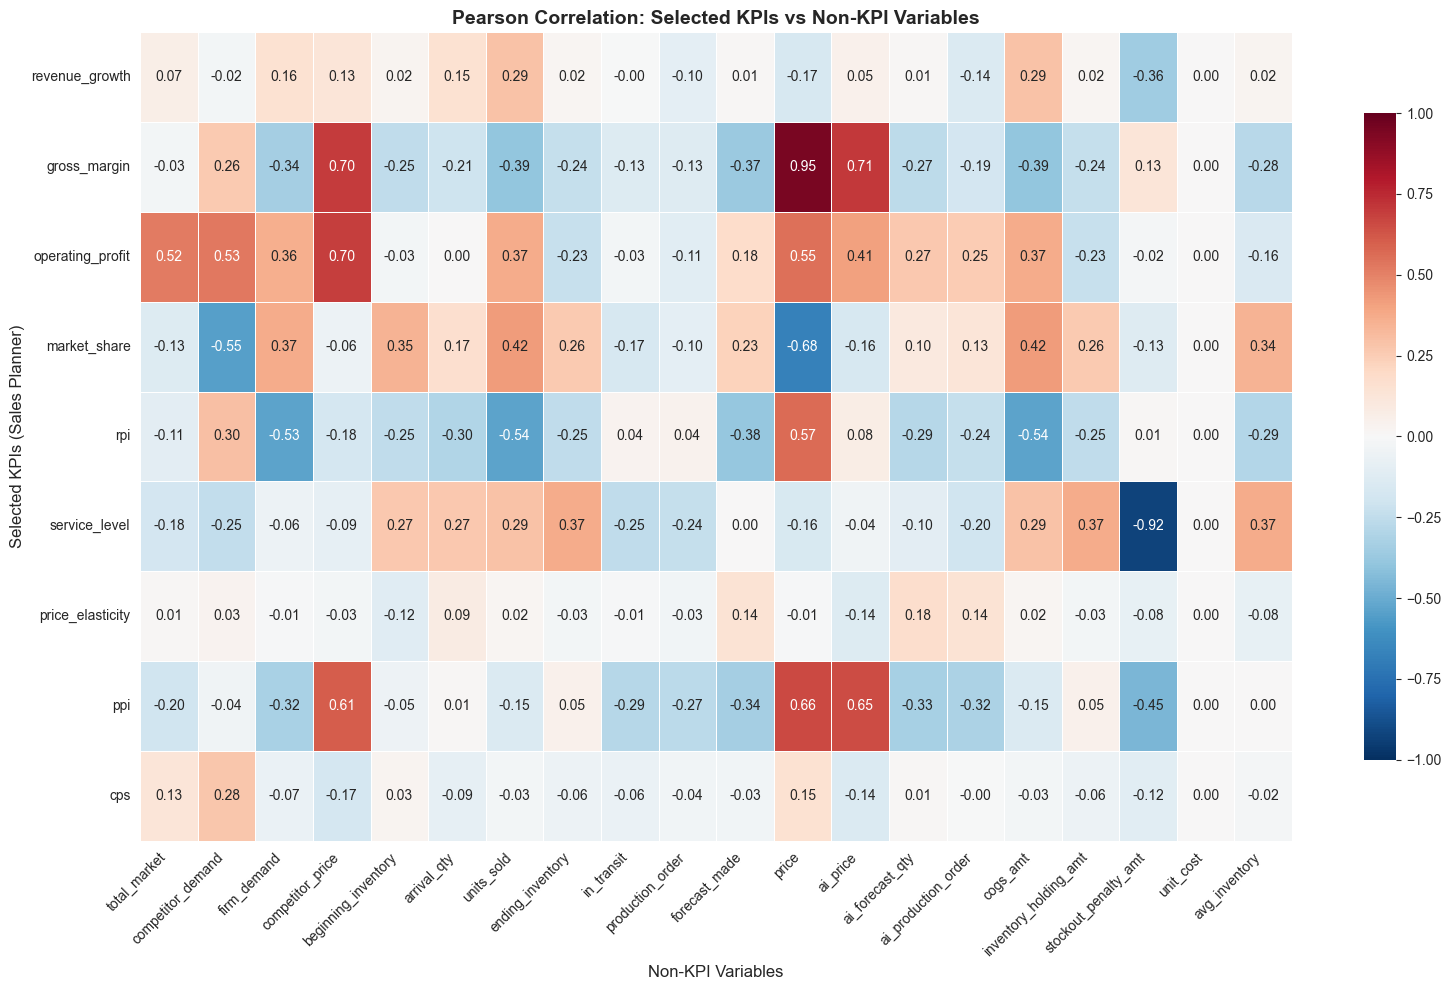

In [18]:
plt.figure(figsize=(16, 10))
sns.heatmap(pearson_r, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Pearson Correlation: Selected KPIs vs Non-KPI Variables',
          fontweight='bold', fontsize=14)
plt.xlabel('Non-KPI Variables', fontsize=12)
plt.ylabel('Selected KPIs (Sales Planner)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 10.2 — Composite Score Bar Chart dengan Elbow Threshold


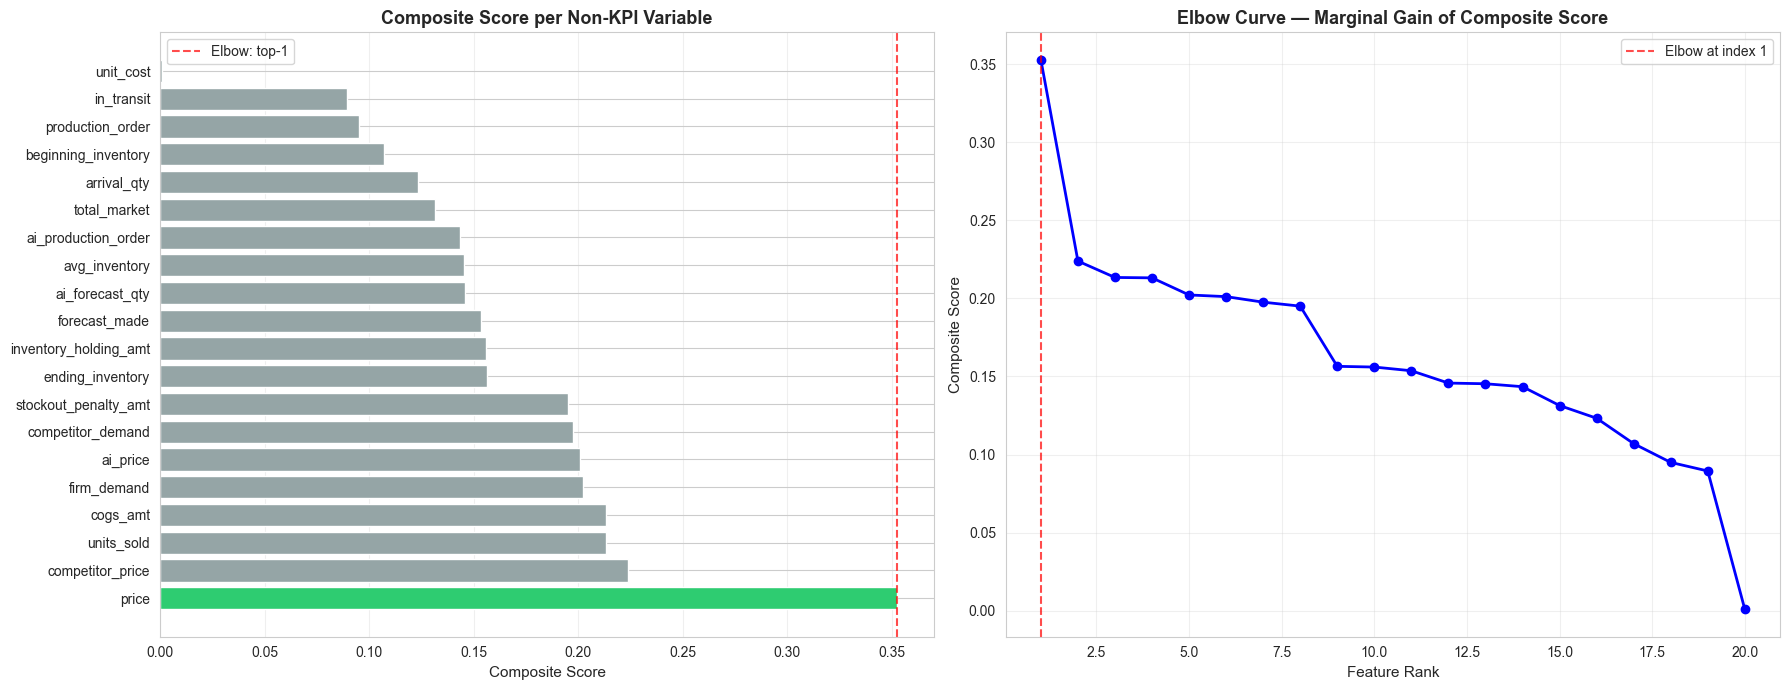

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart composite score
colors = ['#2ecc71' if i < elbow_idx else '#95a5a6'
          for i in range(len(composite_per_method))]
axes[0].barh(range(len(composite_per_method)),
             composite_per_method['composite'].values, color=colors)
axes[0].set_yticks(range(len(composite_per_method)))
axes[0].set_yticklabels(composite_per_method.index)
axes[0].axvline(x=composite_per_method['composite'].values[elbow_idx - 1] if elbow_idx > 0 else 0,
                color='red', linestyle='--', alpha=0.7, label=f'Elbow: top-{elbow_idx}')
axes[0].set_xlabel('Composite Score')
axes[0].set_title('Composite Score per Non-KPI Variable', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Elbow curve
axes[1].plot(range(1, n + 1), scores, 'bo-', linewidth=2, markersize=6)
axes[1].axvline(x=elbow_idx, color='red', linestyle='--',
                alpha=0.7, label=f'Elbow at index {elbow_idx}')
axes[1].set_xlabel('Feature Rank')
axes[1].set_ylabel('Composite Score')
axes[1].set_title('Elbow Curve — Marginal Gain of Composite Score', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 10.3 — RMSE Comparison per KPI


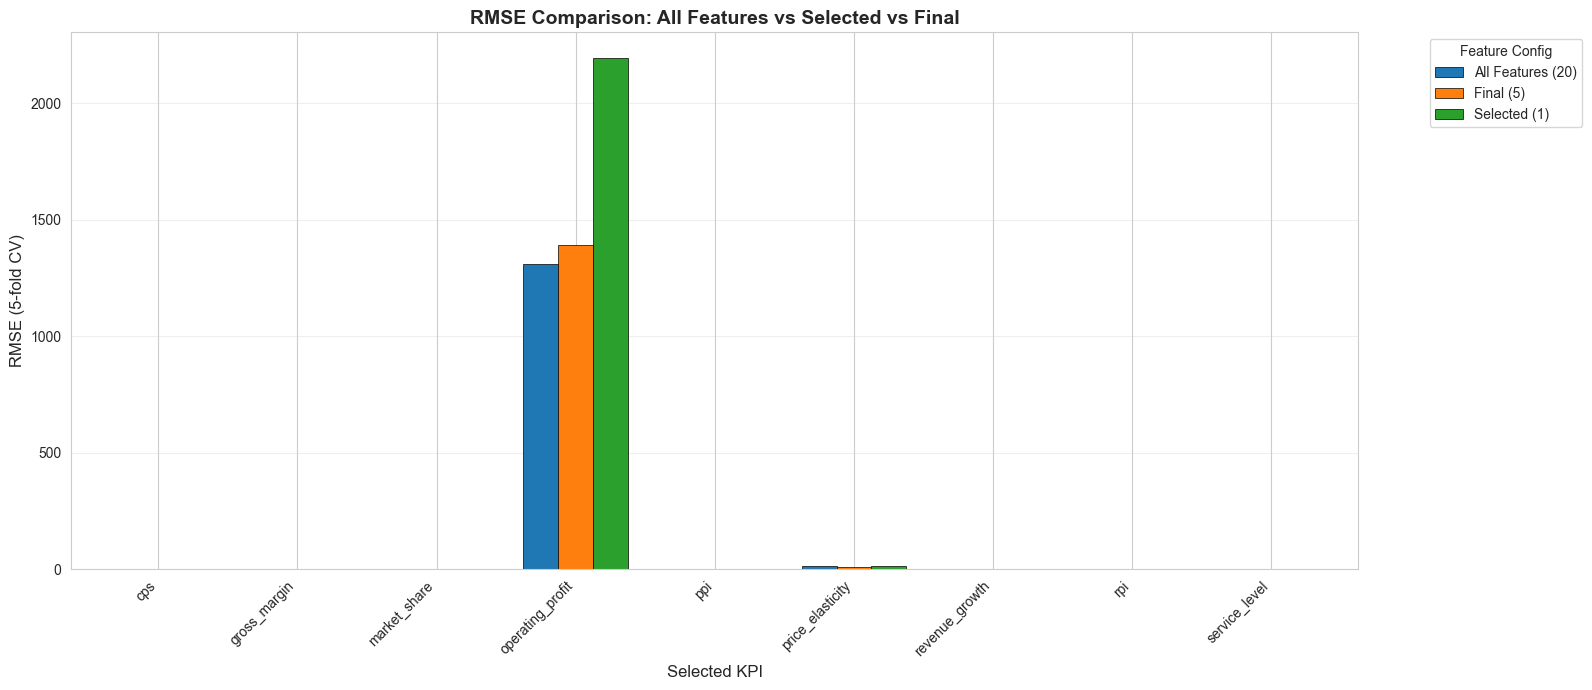

In [20]:
fig, ax = plt.subplots(figsize=(16, 7))

pivot = results_df.pivot_table(index='kpi', columns='config', values='rmse_mean')
pivot.plot(kind='bar', ax=ax, width=0.75, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Selected KPI', fontsize=12)
ax.set_ylabel('RMSE (5-fold CV)', fontsize=12)
ax.set_title('RMSE Comparison: All Features vs Selected vs Final', fontweight='bold', fontsize=14)
ax.legend(title='Feature Config', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


### 10.4 — Scatter Matrix: Top-4 Non-KPI vs Selected KPIs


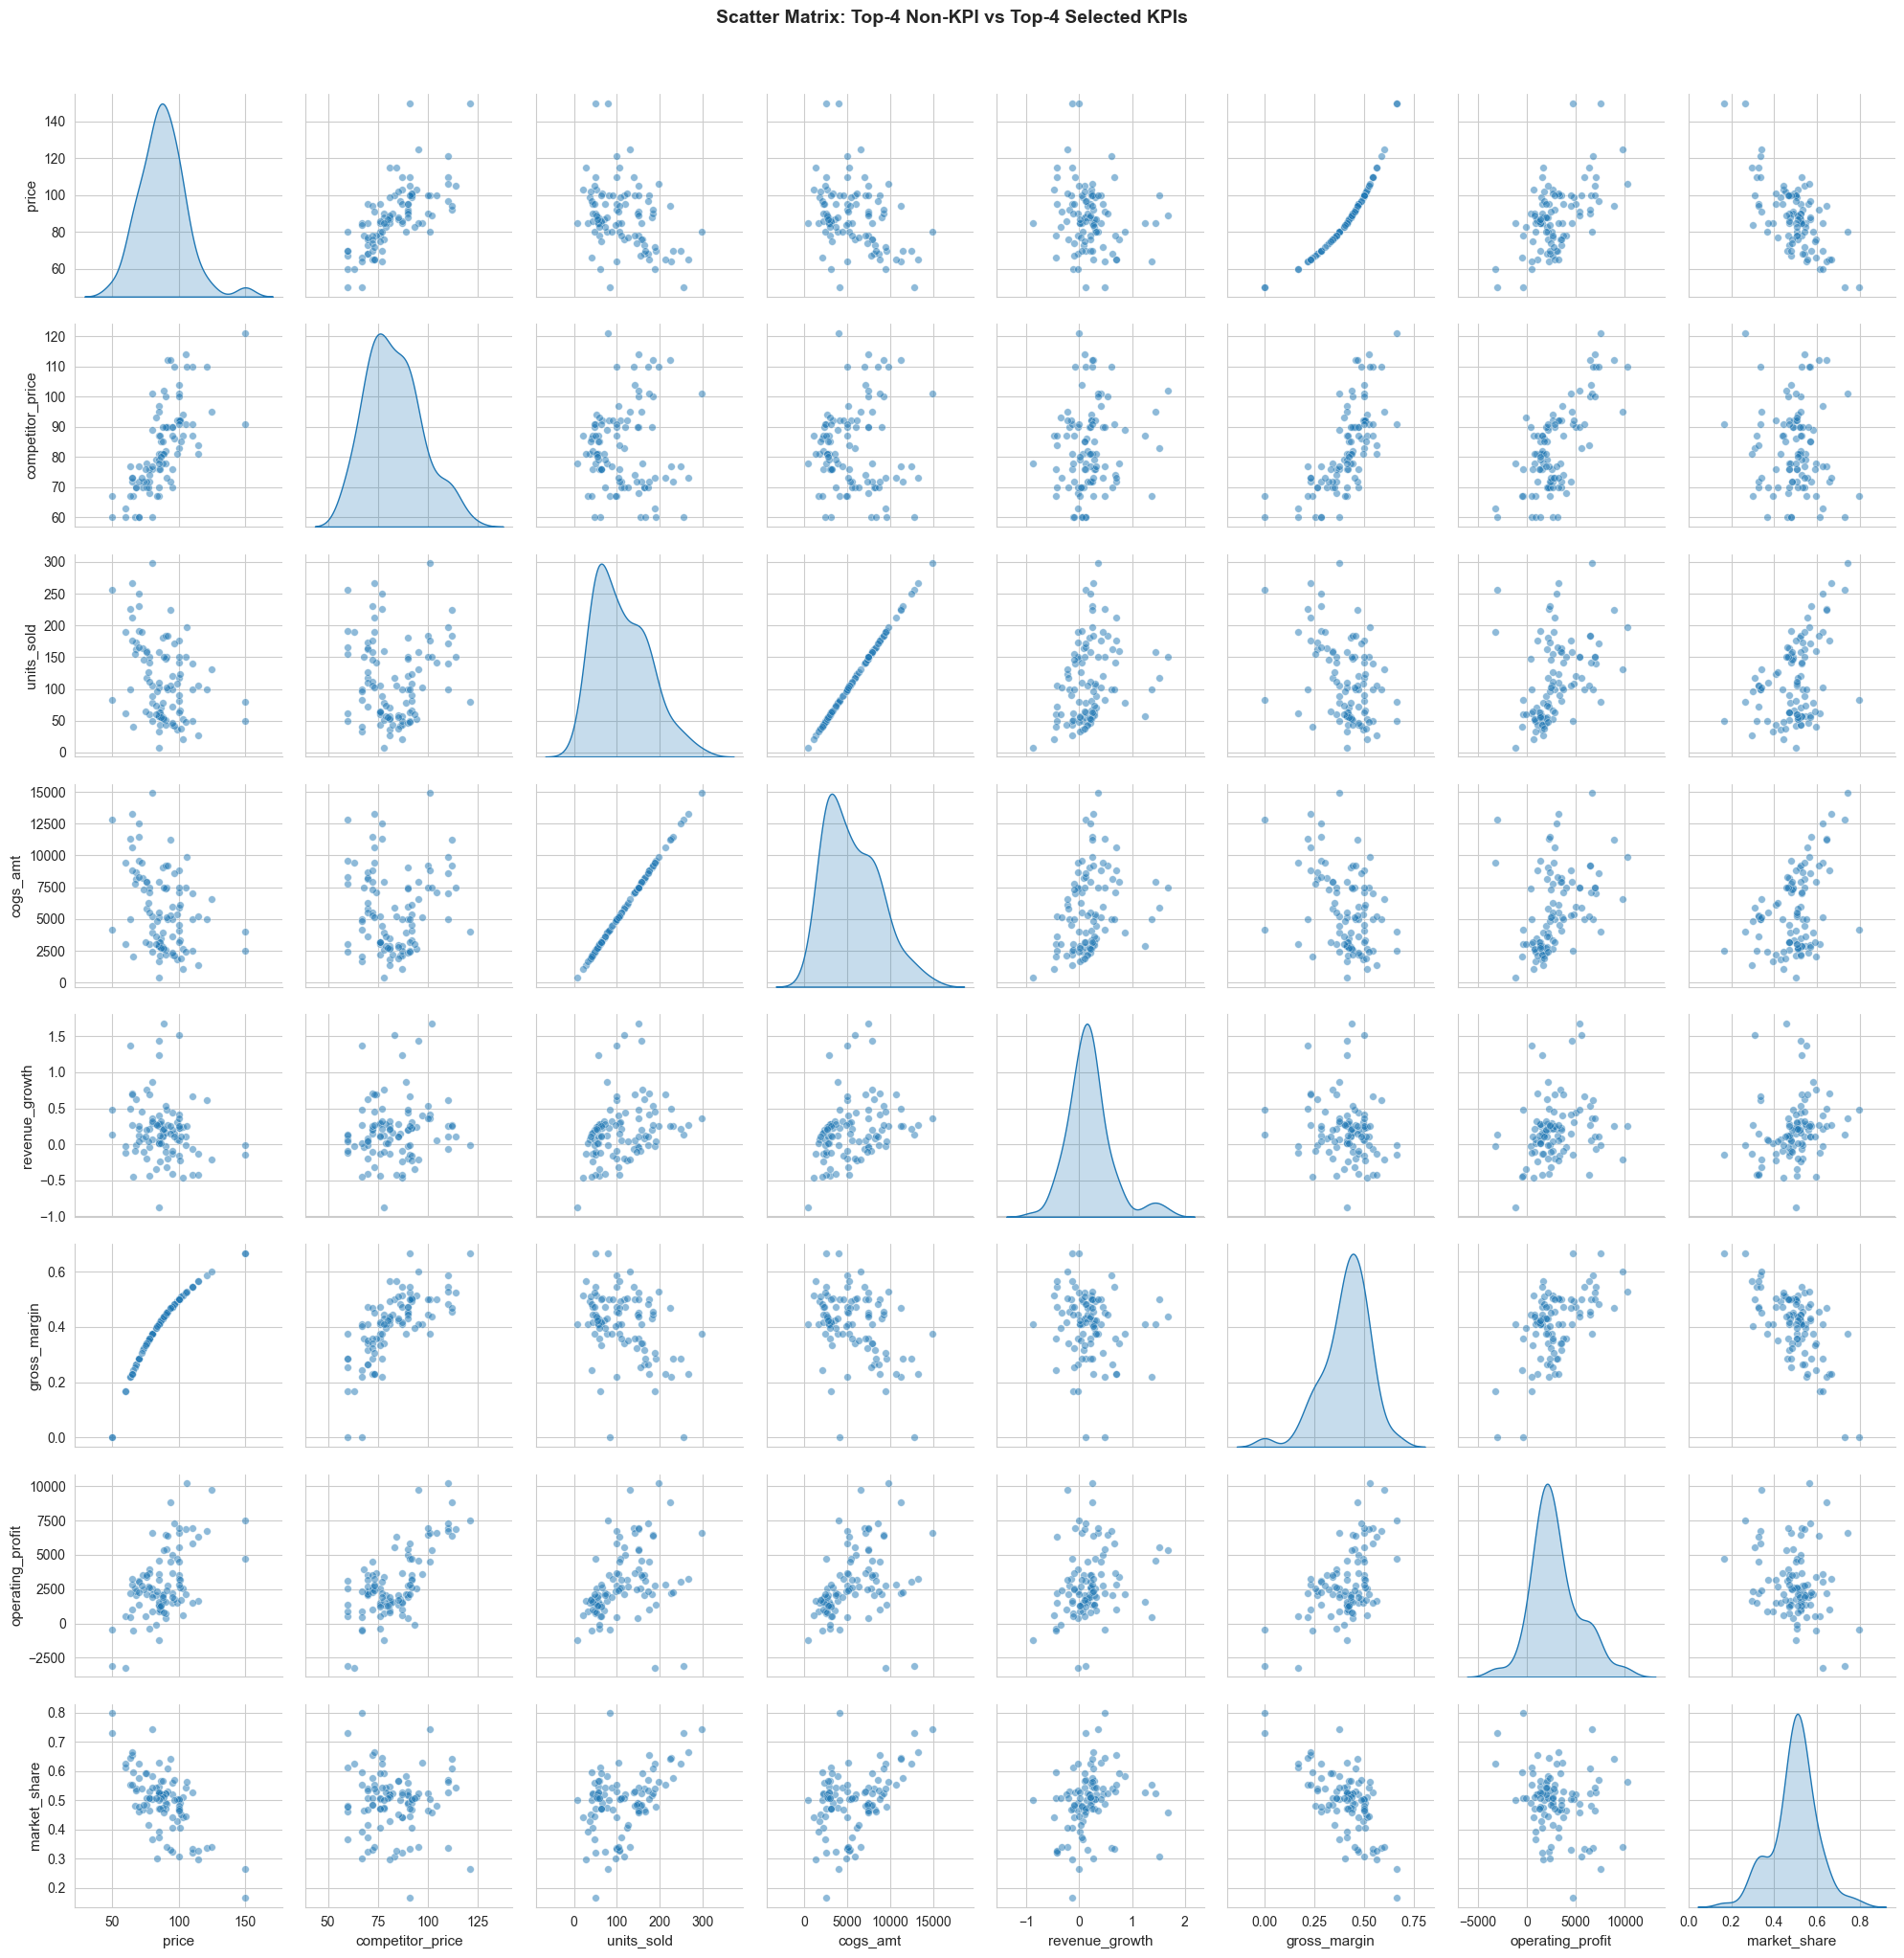

In [21]:
top4 = list(composite_per_method.index[:4])
scatter_cols = top4 + selected_kpis[:4]

sns.pairplot(analyze_df[scatter_cols].dropna(),
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30})
plt.suptitle('Scatter Matrix: Top-4 Non-KPI vs Top-4 Selected KPIs',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 10.5 — Network Graph: KPI-NonKPI Relationships


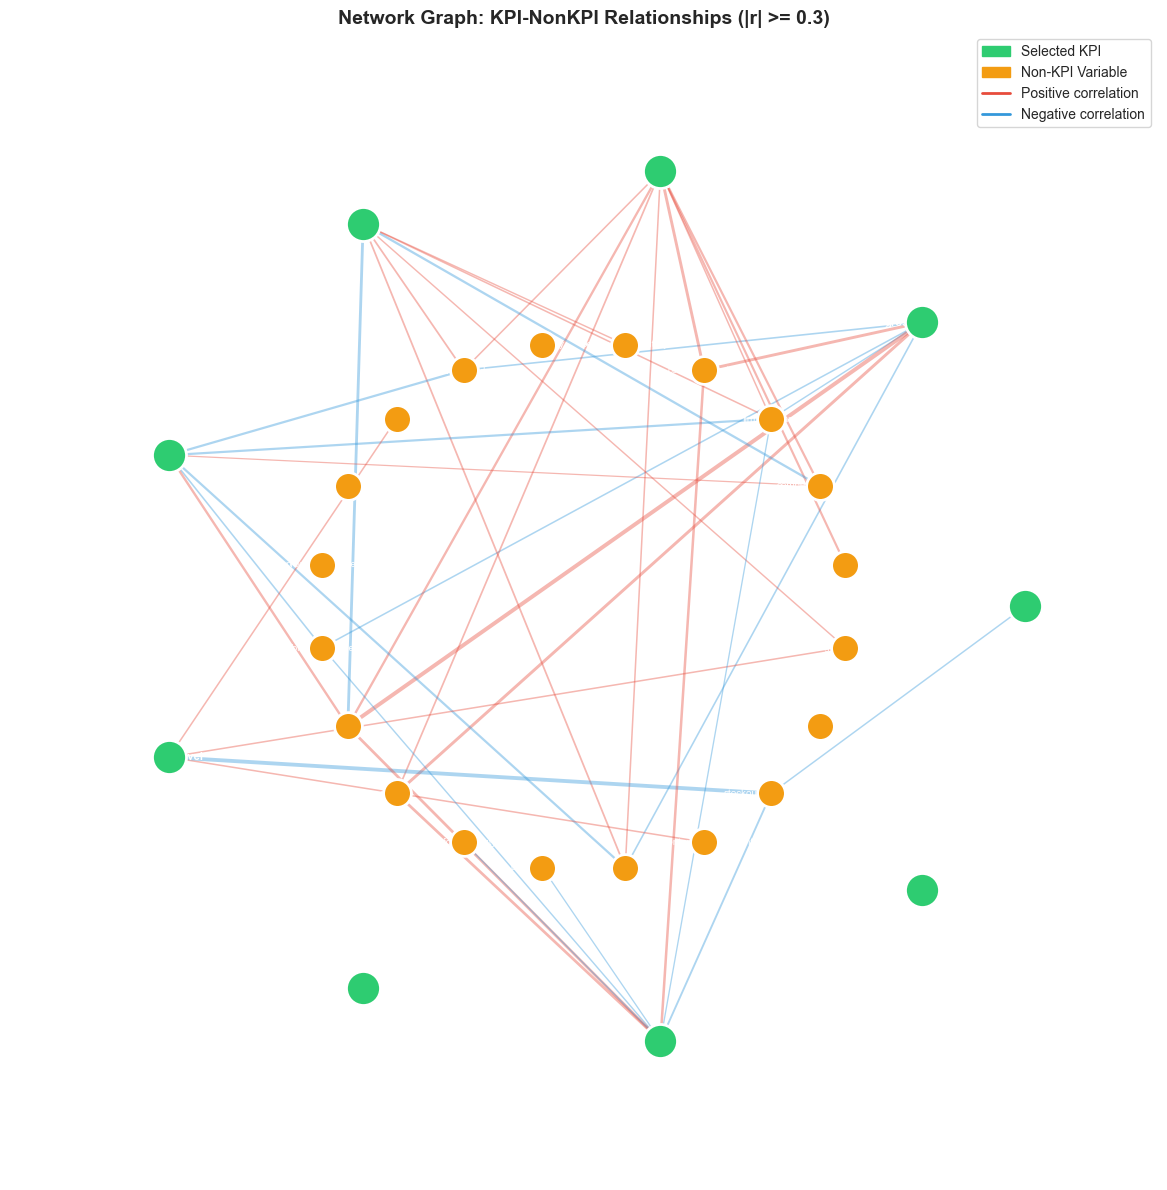

In [22]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 12))

threshold = 0.3  # minimum |r| to show edge

# Positions using circular layout for KPIs and non-KPIs
n_kpi = len(selected_kpis)
n_non = len(non_kpi_columns)

kpi_angles = np.linspace(0, 2*np.pi, n_kpi, endpoint=False)
non_angles = np.linspace(0, 2*np.pi, n_non, endpoint=False) + np.pi/n_non

kpi_pos = {k: (np.cos(a), np.sin(a)) for k, a in zip(selected_kpis, kpi_angles)}
non_pos = {k: (np.cos(a)*0.6, np.sin(a)*0.6) for k, a in zip(non_kpi_columns, non_angles)}

# Draw edges
for kpi in selected_kpis:
    for nk in non_kpi_columns:
        r = pearson_r.loc[kpi, nk]
        if abs(r) >= threshold:
            color = '#e74c3c' if r > 0 else '#3498db'
            width = abs(r) * 3
            ax.plot([kpi_pos[kpi][0], non_pos[nk][0]],
                    [kpi_pos[kpi][1], non_pos[nk][1]],
                    color=color, linewidth=width, alpha=0.4)

# Draw nodes
for kpi, pos in kpi_pos.items():
    ax.scatter(*pos, s=600, c='#2ecc71', edgecolors='white', linewidth=2, zorder=5)
    ax.annotate(kpi, pos, ha='center', va='center', fontsize=8, fontweight='bold', color='white')

for nk, pos in non_pos.items():
    ax.scatter(*pos, s=400, c='#f39c12', edgecolors='white', linewidth=2, zorder=5)
    ax.annotate(nk, pos, ha='center', va='center', fontsize=7, color='white')

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.axis('off')

legend_elements = [
    mpatches.Patch(color='#2ecc71', label='Selected KPI'),
    mpatches.Patch(color='#f39c12', label='Non-KPI Variable'),
    plt.Line2D([0], [0], color='#e74c3c', linewidth=2, label='Positive correlation'),
    plt.Line2D([0], [0], color='#3498db', linewidth=2, label='Negative correlation'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
ax.set_title('Network Graph: KPI-NonKPI Relationships (|r| >= 0.3)',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


## Section 11 — Summary & Export


In [23]:
print('=' * 70)
print('   FEATURE SELECTION SUMMARY — SALES PLANNER')
print('=' * 70)
print()
print(f'Dataset: {len(analyze_df)} rows across {analyze_df["team_name"].nunique()} teams')
print(f'Selected KPIs: {len(selected_kpis)}')
print(f'Non-KPI candidates: {len(non_kpi_columns)}')
print(f'Top-N (elbow): {len(top_n_features)} features')
print(f'Final recommendation: {len(final_features_sorted)} features')
print()
print('Final Feature Ranking (sorted by composite score):')
print('-' * 70)
for i, f in enumerate(final_features_sorted, 1):
    method = 'statistical' if f in top_n_features else 'domain'
    score = composite_per_method.loc[f, 'composite'] if f in composite_per_method.index else '-'
    print(f'  {i:2d}. {f:25s} | score: {score:<8} | source: {method}')
print()
print('RMSE Validation (avg across 9 KPIs):')
print('-' * 70)
for _, row in avg_rmse.iterrows():
    print(f'  {row.name:30s} | RMSE: {row["avg_rmse"]:.4f} +/- {row["std_rmse"]:.4f}')


   FEATURE SELECTION SUMMARY — SALES PLANNER

Dataset: 100 rows across 12 teams
Selected KPIs: 9
Non-KPI candidates: 20
Top-N (elbow): 1 features
Final recommendation: 5 features

Final Feature Ranking (sorted by composite score):
----------------------------------------------------------------------
   1. price                     | score: 0.35269405772829326 | source: statistical
   2. competitor_price          | score: 0.22384362888922946 | source: domain
   3. cogs_amt                  | score: 0.21311486782180697 | source: domain
   4. firm_demand               | score: 0.20215882379845937 | source: domain
   5. unit_cost                 | score: 0.0009655713057532919 | source: domain

RMSE Validation (avg across 9 KPIs):
----------------------------------------------------------------------
  All Features (20)              | RMSE: 147.2665 +/- 436.8339
  Final (5)                      | RMSE: 155.7566 +/- 462.7922
  Selected (1)                   | RMSE: 245.3898 +/- 731.2667


In [24]:
# Export recommendation table (sorted by composite score)
rec_df = pd.DataFrame({
    'rank': range(1, len(final_features_sorted) + 1),
    'feature': final_features_sorted,
    'composite_score': [
        round(composite_per_method.loc[f, 'composite'], 4)
        if f in composite_per_method.index else None
        for f in final_features_sorted
    ],
    'pearson_avg_abs_r': [
        round(pearson_abs[f].mean(), 4)
        if f in pearson_abs.columns else None
        for f in final_features_sorted
    ],
    'spearman_avg_abs_rho': [
        round(spearman_abs[f].mean(), 4)
        if f in spearman_abs.columns else None
        for f in final_features_sorted
    ],
    'mi_avg_score': [
        round(mi_scores[f].mean(), 4)
        if f in mi_scores.columns else None
        for f in final_features_sorted
    ],
    'source': [
        'elbow' if f in top_n_features else 'domain'
        for f in final_features_sorted
    ],
})

rec_path = '../df_feature_selection_recommendation.csv'
rec_df.to_csv(rec_path, index=False)
print(f'Recommendation table saved: {rec_path}')
print()
rec_df


Recommendation table saved: ../df_feature_selection_recommendation.csv



,rank,feature,composite_score,pearson_avg_abs_r,spearman_avg_abs_rho,mi_avg_score,source
0,1,price,0.3527,0.4338,0.4140,0.5143,elbow
1,2,competitor_price,0.2238,0.2959,0.2901,0.1914,domain
2,3,cogs_amt,0.2131,0.2786,0.2839,0.1701,domain
3,4,firm_demand,0.2022,0.2474,0.2717,0.2038,domain
4,5,unit_cost,0.0010,0.0000,0.0000,0.0080,domain


In [25]:
# Export RMSE comparison
rmse_path = '../df_feature_selection_rmse.csv'
results_df.to_csv(rmse_path, index=False)
print(f'RMSE results saved: {rmse_path}')


RMSE results saved: ../df_feature_selection_rmse.csv


---
**Notebook selesai.** Rekomendasi fitur untuk Sales Planner telah dihasilkan
berdasarkan kombinasi analisis statistik (Pearson, Spearman, Mutual Information)
dan domain knowledge dari panduan `kpis.md`.
